In [264]:
import pandas as pd
import io
import requests
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt



# Data

In [265]:
def getDF(league,season):
    "Function to pull data from website football-data.co.uk"
    #Inputs
    #   League: 2 letter string with country and division reference (I1 for Italian 1st division, I2 for Italian Second Division ,... [EPL is referenced as E0])
    #   Season: string to reference the season to get (0405 for the 2004/2005 season)
    #Returns pandas dataframe of football-data data for inputted league and season
    rooturl="https://www.football-data.co.uk/mmz4281/"
    url= rooturl+str(season)+'/'+league+'.csv'
    s0=requests.get(url).content
    df=pd.read_csv(io.StringIO(s0.decode('utf-8')))
    #Handle Renaming of Odds Columns for Over/Under 2.5 Odds from 19/20 onwards
    RENAME = {
    "BbAv>2.5": "Avg>2.5",
    "BbAv<2.5": "Avg<2.5",
    "BbMx>2.5": "Max>2.5",
    "BbMx<2.5": "Max<2.5",
    }
    df=df.rename(RENAME, axis=1)
    KEEP = ["Div","Date","HomeTeam","AwayTeam","FTHG","FTAG","FTR","HS", "AS","Avg>2.5","Avg<2.5"]
    df=df[KEEP].reindex(columns=KEEP)
    df['Date']=pd.to_datetime(df["Date"], dayfirst=True, format='mixed')
    return df

def year2Str(season:int)->str:
    "Function to convert integer season to 4 character string for season in order to pull data from football-data"
    #Input: season as an integer value (506 for the 05/06 season)
    #Returns season as a string ('05/06' in the case of 506 being the input)
    return str(season).zfill(4)

In [266]:
#Seasons we want to pull data for are 05/06-25/26
seasons=np.arange(506,2527,101)
seasons=list(map(year2Str,seasons))
#We will pull data from the  5 major leagues
leagues=['D1','E0','F1','I1','SP1']
#seasonDict stores the dataframes in a dictionary, key being the league
leagueDict={}
#Populating seasonDict with nested for loop
for l in leagues:
    leagueDict[l]={}
    seasonList=[]
    for s in seasons:
        sdf=getDF(l,s)
        sdf.insert(0,'Season',s)
        seasonList.append(sdf)
    leagueDict[l]=pd.concat(seasonList)
    leagueDict[l]=leagueDict[l].reset_index(drop=True)
    leagueDict[l].insert(0,"match_id",l+'_'+leagueDict[l].index.astype(str))


In [268]:
#Check dates have been processed correctly
#All dates should fall between August and May
for l in leagueDict.keys():
    print(l)
    print(leagueDict[l].groupby("Season")["Date"].agg(["min","max"]))

D1
              min        max
Season                      
0506   2005-08-05 2006-05-13
0607   2006-08-11 2007-05-19
0708   2007-08-10 2008-05-17
0809   2008-08-15 2009-05-23
0910   2009-08-07 2010-05-08
1011   2010-08-20 2011-05-14
1112   2011-08-05 2012-05-05
1213   2012-08-24 2013-05-18
1314   2013-08-09 2014-05-10
1415   2014-08-22 2015-05-23
1516   2015-08-14 2016-05-14
1617   2016-08-26 2017-05-20
1718   2017-08-18 2018-05-12
1819   2018-08-24 2019-05-18
1920   2019-08-16 2020-06-27
2021   2020-09-18 2021-05-22
2122   2021-08-13 2022-05-14
2223   2022-08-05 2023-05-27
2324   2023-08-18 2024-05-18
2425   2024-08-23 2025-05-17
2526   2025-08-22 2026-05-16
E0
              min        max
Season                      
0506   2005-08-13 2006-05-07
0607   2006-08-19 2007-05-13
0708   2007-08-11 2008-05-11
0809   2008-08-16 2009-05-24
0910   2009-08-15 2010-05-09
1011   2010-08-14 2011-05-22
1112   2011-08-13 2012-05-13
1213   2012-08-18 2013-05-19
1314   2013-08-17 2014-05-11
1415   2

# Feature Engineering



In [269]:
def formFeatures(matches:pd.DataFrame, window=5, tranCols=["FTHG","FTAG","HS","AS"],statsNames=["GF","GA","SF","SA"]) ->pd.DataFrame:
    "Function to build form features from imported DataFrame. The DataFrame long contains 1 row per team per match to calculate the rolling form statistics."
    #Inputs: matches->DataFrame with columns ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'Avg>2.5', 'Avg<2.5', 'Season'] 
    #       window->Number of matches in the rolling window
    #       tranCols->Names of columns to be transformed (MUST BE IN ORDERED TEAM PAIRS FOR EACH STATISTIC)
    #       statsNames-> Names of transformed columns (MUST BE IN ORDERED TEAM PAIRS FOR EACH STATISTIC, WITH CORRESPONDING VALUES FOR tranCols)
    #Output: Same DataFrame with added columns: ['HL{window}GS', 'AL{window}GS','HL{window}GC', 'AL{window}GC'...]
    #       HL{n},AL{n} -> Home Last n matches, Away Last n matches
    #       GS,GC -> Goals Scored, Goals Conceded
    #       SF,SA -> Shots For, Shots Against
    assert len(tranCols) == len(statsNames), "column and stat lists must be same length"
    assert len(tranCols) % 2 == 0, "columns must be in for/against pairs"
    def homeAwayMapper(tranCols=tranCols,statsNames=statsNames):
        "Function that maps stats to home and away"
        #Inputs: tranCols -> Columns in original DataFrame to be transformed. 
        #       statsNames -> Columns in output dataframe
        '''Input lists must be in the format where columns and stats are grouped in with their inverse (i.e. same stat for opposite team).
        For example: The lists ['FTHG','FTAG','HS','AS'], ["GF","GA","SF","SA"] works, the lists ['FTHG','HS','FTAG','AS'], ["GF","GA","SF","SA"] will not map properly
        '''
        #Outputs: Ordered mappings for each column and stat to use for the home and away tables.
        homeMap={'HomeTeam':'Team', 'AwayTeam':'Opponent'}
        awayMap={'HomeTeam':'Opponent', 'AwayTeam':'Team'}
        for h, a, fo, ag in zip(tranCols[0::2], tranCols[1::2],statsNames[0::2], statsNames[1::2]):
            homeMap.update({h:fo,a:ag})
            awayMap.update({a:fo,h:ag})
        return homeMap, awayMap
    homeMap,awayMap=homeAwayMapper()
    home = matches[["match_id","Date","Season","HomeTeam","AwayTeam","FTR"]+list(tranCols)].rename(columns=homeMap)
    home["venue"] = "H"
    away = matches[["match_id","Date","Season","HomeTeam","AwayTeam","FTR"]+list(tranCols)].rename(columns=awayMap)
    away["venue"] = "A"
    long=pd.concat([home,away], ignore_index=True).sort_values('Date') 
    def prior_mean(s, n=window):
        "Mean over the previous n matches, excluding the current one."
        #Input: s->Column swith numeric values, n-> number of previous values for mean to be taken over:
        #Output: Column where each cell has the mean of n previous values (first n values are na).
        return s.shift(1).rolling(n).mean()
    g = long.groupby("Team")

    long[["L"+str(window) + c for c in statsNames]] = g[statsNames].transform(prior_mean)
    longH = long[long.venue=="H"].rename({f"L{window}{s}": f"HL{window}{s}" for s in statsNames}, axis=1)
    longA = long[long.venue=="A"].rename({f"L{window}{s}": f"AL{window}{s}" for s in statsNames}, axis=1)

    matches=matches.merge(longH[["match_id"]+["HL"+str(window) + c for c in statsNames]], on='match_id', how='left')
    return matches.merge(longA[["match_id"]+["AL"+str(window) + c for c in statsNames]], on='match_id', how='left')





In [325]:
#Check formFeatures works as intended
assert(len(formFeatures(leagueDict['D1']))==len(leagueDict['D1'])) 

aSet=leagueDict['D1'].head(100)
aFormSet=formFeatures(aSet)
checkSet=aFormSet.loc[(aFormSet['HomeTeam']=='Bayern Munich')|(aFormSet['AwayTeam']=='Bayern Munich')|(aFormSet['HomeTeam']=='Ein Frankfurt')|(aFormSet['AwayTeam']=='Ein Frankfurt')].head(11)
display(checkSet)

,match_id,Season,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,...,PricePrOver,MarketPrOver,HL5GF_y,HL5GA_y,HL5SF_y,HL5SA_y,AL5GF_y,AL5GA_y,AL5SF_y,AL5SA_y
0,D1_0,0506,D1,2005-08-05,Bayern Munich,M'gladbach,3,0,H,19.0,...,0.657895,0.597884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,D1_7,0506,D1,2005-08-07,Ein Frankfurt,Leverkusen,1,4,A,17.0,...,0.613497,0.559459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,D1_11,0506,D1,2005-08-13,Hertha,Ein Frankfurt,2,0,H,13.0,...,0.641026,0.587302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,D1_13,0506,D1,2005-08-13,Leverkusen,Bayern Munich,2,5,A,15.0,...,0.632911,0.582011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,D1_18,0506,D1,2005-08-27,Bayern Munich,Hertha,3,0,H,18.0,...,0.649351,0.591512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,D1_19,0506,D1,2005-08-27,Ein Frankfurt,Nurnberg,1,0,H,11.0,...,0.606061,0.555256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,D1_27,0506,D1,2005-09-10,Hannover,Ein Frankfurt,2,0,H,13.0,...,0.588235,0.539295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,D1_32,0506,D1,2005-09-10,Nurnberg,Bayern Munich,1,2,A,11.0,...,0.649351,0.595801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,D1_36,0506,D1,2005-09-17,Bayern Munich,Hannover,1,0,H,11.0,...,0.653595,0.598425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,D1_39,0506,D1,2005-09-17,Hamburg,Ein Frankfurt,1,1,D,12.0,...,0.628931,0.577128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Adding Target Columns and Market Implied Probabilities
featDict={}
for l in leagueDict.keys():
    featDict[l]=formFeatures(leagueDict[l])
    featDict[l]['Over25']=((leagueDict[l]['FTHG']+ leagueDict[l]['FTAG']) > 2.5).astype(int)
    featDict[l]['PricePrOver']=1/(leagueDict[l]['Avg>2.5'])
    featDict[l]['MarketPrOver']=1/(leagueDict[l]['Avg>2.5'])/((1/leagueDict[l]['Avg>2.5'])+(1/leagueDict[l]['Avg<2.5']))

## Model Building and Assessment

In [275]:
FEATURES=['HL5GF','HL5GA','HL5SF','HL5SA','AL5GF','AL5GA','AL5SF','AL5SA']
test_seasons=np.arange(708,2527,101)
test_seasons=list(map(year2Str,test_seasons))
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf",   LogisticRegression(max_iter=1000)),
])

In [ ]:
preds=[]

for l in featDict.keys(): 
    df=featDict[l]
    for s in test_seasons:
        train = df[df.Season < s].dropna(subset=FEATURES)
        test  = df[df.Season == s].dropna(subset=FEATURES+['PricePrOver','MarketPrOver'])
        out=test[["Season","Over25","PricePrOver","MarketPrOver"]].copy().rename(columns={'PricePrOver':'p_price','MarketPrOver':'p_market'})
        pipe.fit(train[FEATURES], train["Over25"])
        p=(pipe.predict_proba(test[FEATURES])[:,1])
        out['League']=l
        out['p_base']=train['Over25'].mean()
        out['p_model']=p
        preds.append(out)

predsDF=pd.concat(preds)[['League', 'Season','Over25','p_price', 'p_market' ,'p_base','p_model']]
predsDF


,League,Season,Over25,p_price,p_market,p_base,p_model
612,D1,0708,1,0.497512,0.462567,0.509946,0.467199
614,D1,0708,1,0.613497,0.566489,0.509946,0.540668
615,D1,0708,0,0.537634,0.502674,0.509946,0.685435
616,D1,0708,0,0.515464,0.477089,0.509946,0.590806
617,D1,0708,0,0.606061,0.560000,0.509946,0.560580
...,...,...,...,...,...,...,...
7975,SP1,2526,0,0.606061,0.564644,0.492754,0.494816
7976,SP1,2526,1,0.546448,0.509383,0.492754,0.379357
7977,SP1,2526,1,0.680272,0.636139,0.492754,0.514272
7978,SP1,2526,1,0.699301,0.652068,0.492754,0.456956


In [ ]:
def returnMetrics(g):
    return pd.Series({
    'n':len(g),
    'brier_mkt': brier_score_loss(g.Over25, g.p_market),
    'brier_base': brier_score_loss(g.Over25, g.p_base),
    'brier_model': brier_score_loss(g.Over25, g.p_model),
    'brier_price': brier_score_loss(g.Over25, g.p_price),
    'll_mkt': log_loss(g.Over25, g.p_market),
    'll_base': log_loss(g.Over25, g.p_base),
    'll_price': log_loss(g.Over25, g.p_price),
    'll_model': log_loss(g.Over25, g.p_model)
    })
scores=predsDF.groupby(['League','Season']).apply(lambda g:returnMetrics(g))

In [ ]:
FORECASTERS = {"p_model": "Model", "p_market": "Market"}
frames = []
for col, name in FORECASTERS.items():
    d = predsDF[["League", "Over25", col]].copy()
    d["bin"] = d.groupby("League")[col].transform(
        lambda s: pd.qcut(s, 5, labels=False)
    )
    g = (d.groupby(["League", "bin"])
           .agg(n=("Over25", "size"),
                obs=("Over25", "mean"),
                pred=(col, "mean"))
           .reset_index())
    g["forecaster"] = name
    frames.append(g)

calDF = pd.concat(frames, ignore_index=True)

# Results

In [601]:

ll_cols=['ll_mkt', 'll_base', 'll_price','ll_model']
ll_labels=['Market','Base','Price','Model']
cal_cols=['ll_mkt', 'll_base', 'll_price','ll_model']
cal_labels=['Market','Model']
def plotLLCal(leagues=leagues, ll_cols=ll_cols,ll_labels=ll_labels,cal_cols=cal_cols,cal_labels=cal_labels):
    fig,axs=plt.subplots(nrows=len(leagues),ncols=2, sharex='col', sharey='col',figsize=(10,16))
    for ax,l in zip(axs,leagues):
        s=scores.loc[l]
        ax[0].set_title(f"{l} Log Loss by Year")
        for col,lab in zip(ll_cols,ll_labels):
            ax[0].plot(s.index,s[col],label=lab,marker='o',fillstyle='none')
        ax[0].set_ylabel('Log Loss')
        ax[1].set_title(f"{l} Model Calibration")
        for col, lab in zip(cal_cols,cal_labels):
            c = calDF[(calDF['League'] == l) & (calDF['forecaster'] == lab)]
            ax[1].plot(c["pred"], c["obs"], marker="o", fillstyle="none", label=lab)
        ax[1].axline([0.5,0.5],slope=1, c='grey', linestyle='--', linewidth=0.5)
        ax[1].set_ylabel('Observed Probability')
    axs[0][0].legend(loc="upper right")
    axs[0][1].legend(loc="lower right")
    axs[-1][0].tick_params(rotation=90)
    axs[-1][1].set_xlabel('Predicted Probability')
    fig.suptitle('Log Loss and Calibration Plots by League',y=1)
    fig.tight_layout()


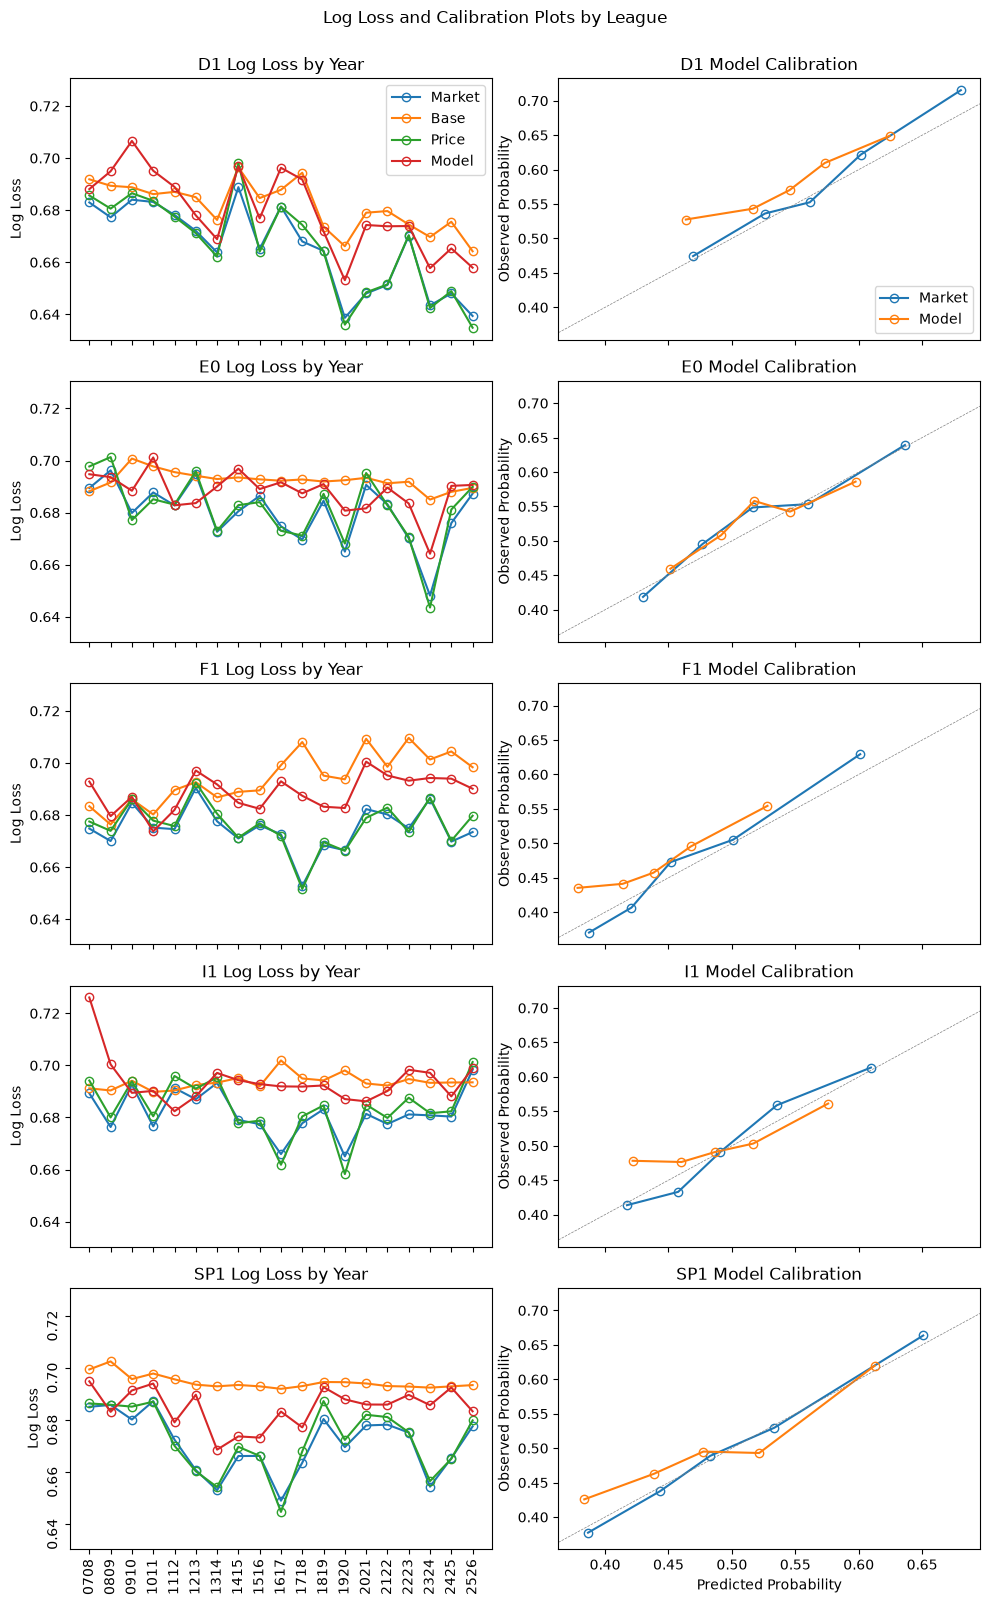

In [602]:
plotLLCal()